# 03 — CCA Baseline

**Owner:** Ishanvir

**Reference:** Lin, Z., Zhang, C., Wu, W., & Gao, X. (2007). *Frequency Recognition Based on Canonical Correlation Analysis for SSVEP-Based BCIs.* IEEE Trans. Biomed. Eng. 54(6):1172–1176.

**This notebook is a pedagogical wrapper** around `src/ssvep/classifiers/cca.py`. It does not reimplement CCA; it loads the canonical preprocessing path, runs `CCAClassifier`, and reports the headline cross-subject 4-block LOBO accuracy.

CCA decodes SSVEP by maximizing the canonical correlation between the multichannel EEG and a small basis of canonical sin/cos reference waveforms at each candidate stimulus frequency. The predicted class is the frequency whose reference best correlates with the EEG. 

In [1]:
import os
from pathlib import Path
# Notebook may execute from notebooks/ — chdir to repo root so data/raw resolves
_here = Path.cwd()
_root = next((p for p in [_here, *_here.parents] if (p / 'data' / 'raw').exists()), None)
if _root and Path.cwd() != _root:
    os.chdir(_root)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import CCA as SklearnCCA

from ssvep.io import load_all
from ssvep.features import cca_reference_signals
from ssvep.classifiers import CCAClassifier
from ssvep.evaluation import leave_one_block_out_cv, itr


## 1. Load data

`load_all()` reads the 4 hackathon `.mat` files from `data/raw/`, applies the canonical 3–45 Hz bandpass + 50 Hz notch on the **continuous** signal (Chen 2015 convention, pre-epoch filtering avoids per-trial FIR edge artifacts), then epochs each trial 0.14 s post-trigger for the requested `window_s`.


In [12]:
d = load_all(window_s=3.0)
print(f"X.shape       : {d['X'].shape}        (n_trials, n_channels, n_samples)")
print(f"y.shape       : {d['y'].shape}")
print(f"blocks unique : {sorted(set(d['blocks'].tolist()))}     # 0,1 = subject 1; 2,3 = subject 2")
print(f"fs            : {d['fs']} Hz")
print(f"stim_freqs    : {d['stim_freqs']}")
print(f"ch_names      : {d['ch_names']}")


X.shape       : (80, 8, 768)        (n_trials, n_channels, n_samples)
y.shape       : (80,)
blocks unique : [0, 1, 2, 3]     # 0,1 = subject 1; 2,3 = subject 2
fs            : 256.0 Hz
stim_freqs    : [ 9. 10. 12. 15.]
ch_names      : ['PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2']


## 2. Build the CCA reference signals

`cca_reference_signals(freqs, n_harmonics, fs, n_samples)` returns shape `(n_freqs, 2*H, n_samples)`. For each frequency `f` and harmonic `h ∈ 1..H`, two rows are emitted: `sin(2π·h·f·t)` and `cos(2π·h·f·t)`.


refs.shape: (1, 4, 768)    (n_freqs=1, 2*H=4, n_samples=768)


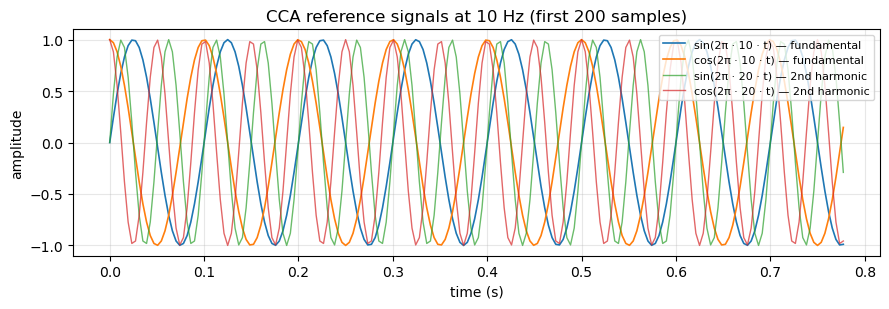

In [13]:
refs_10hz = cca_reference_signals(freqs=[10.0], n_harmonics=2, fs=d['fs'], n_samples=d['X'].shape[-1])
print(f"refs.shape: {refs_10hz.shape}    (n_freqs=1, 2*H=4, n_samples=768)")

t = np.arange(refs_10hz.shape[-1]) / d['fs']
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t[:200], refs_10hz[0, 0, :200], label='sin(2π · 10 · t) — fundamental', lw=1.2)
ax.plot(t[:200], refs_10hz[0, 1, :200], label='cos(2π · 10 · t) — fundamental', lw=1.2)
ax.plot(t[:200], refs_10hz[0, 2, :200], label='sin(2π · 20 · t) — 2nd harmonic', lw=1.0, alpha=0.7)
ax.plot(t[:200], refs_10hz[0, 3, :200], label='cos(2π · 20 · t) — 2nd harmonic', lw=1.0, alpha=0.7)
ax.set_xlabel('time (s)'); ax.set_ylabel('amplitude'); ax.legend(loc='upper right', fontsize=8)
ax.set_title('CCA reference signals at 10 Hz (first 200 samples)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Single-trial demonstration

Pick one trial, build references for all 4 candidate frequencies, fit `CCA(n_components=1)` per frequency, take the canonical correlation ρ, and predict by argmax over ρ.


In [14]:
# Pick the first trial of class 1 (10 Hz) from block 0
trial_idx = int(np.where((d['y'] == 1) & (d['blocks'] == 0))[0][0])
x = d['X'][trial_idx]                       # shape (8, 768)
n_samples = x.shape[-1]
all_refs = cca_reference_signals(d['stim_freqs'], n_harmonics=2, fs=d['fs'], n_samples=n_samples)

rhos = np.zeros(len(d['stim_freqs']))
for k in range(len(d['stim_freqs'])):
    cca = SklearnCCA(n_components=1, max_iter=500)
    u, v = cca.fit_transform(x.T, all_refs[k].T)
    rhos[k] = float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])

print(f"trial #{trial_idx} (true class = {d['y'][trial_idx]} → {d['stim_freqs'][d['y'][trial_idx]]} Hz)")
print(f"  ρ per candidate frequency: {dict(zip(d['stim_freqs'].tolist(), [round(r, 3) for r in rhos.tolist()]))}")
print(f"  argmax ρ → predicted class {int(np.argmax(rhos))} → {d['stim_freqs'][int(np.argmax(rhos))]} Hz")


trial #2 (true class = 1 → 10.0 Hz)
  ρ per candidate frequency: {9.0: 0.274, 10.0: 0.758, 12.0: 0.279, 15.0: 0.297}
  argmax ρ → predicted class 1 → 10.0 Hz


## 4. Single-block demo (`CCAClassifier`)

Score every trial of block 0 (subject 1, training 1) using the production `CCAClassifier`. Subject 1 produces a textbook SSVEP response; CCA hits 1.000.


In [15]:
clf = CCAClassifier(stim_freqs=d['stim_freqs'], fs=d['fs'], n_harmonics=2)
clf.fit(d['X'], d['y'])     # no-op

mask_block0 = d['blocks'] == 0
preds = clf.predict(d['X'][mask_block0])
truth = d['y'][mask_block0]
acc_block0 = float((preds == truth).mean())
print(f"Block 0 (subject 1, training 1): accuracy = {acc_block0:.3f}    (expected 1.000)")
print(f"  predicted: {preds.tolist()}")
print(f"  truth    : {truth.tolist()}")


Block 0 (subject 1, training 1): accuracy = 1.000    (expected 1.000)
  predicted: [3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0]
  truth    : [3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0]


## 5. Cross-subject 4-block LOBO

`leave_one_block_out_cv` iterates the 4 blocks: for each held-out block, train (no-op for CCA) on the other 3, score on the held-out one. Returns per-block accuracies + mean ± std.

In [16]:
factory = lambda: CCAClassifier(stim_freqs=d['stim_freqs'], fs=d['fs'], n_harmonics=2)
result = leave_one_block_out_cv(d['X'], d['y'], d['blocks'], factory)
print(f"per-block accuracies: {result['per_block']}")
print(f"mean ± std         : {result['mean']:.3f} ± {result['std']:.3f}")
print(f"ITR @ 3.0s window  : {itr(result['mean'], n_classes=4, window_s=3.0):.2f} bits/min")


per-block accuracies: {0: 1.0, 1: 1.0, 2: 0.7, 3: 0.65}
mean ± std         : 0.838 ± 0.163
ITR @ 3.0s window  : 22.04 bits/min


## 6. Discussion: The universality bottleneck

The per-block breakdown reveals the structure of the problem. Subject 1 (blocks 0 and 1) hits ceiling: CCA's matched-filter optimality is theoretically tight on this stimulus design (4 widely spaced frequencies, no harmonic overlap up to the fifth harmonic, clean occipital response). Subject 2 (blocks 2 and 3) sits at 0.65–0.70, well above the 0.25 chance level, but a long way from ceiling.

This is the universality problem documented by Guger et al. (2012): SSVEP BCIs work cleanly for some subjects and poorly for others. The 0.838 mean is not a property of the algorithm; it is the average of subject 1 at ceiling and subject 2's weaker response.

The question for the rest of the ablation is whether any classifier can recover headroom on subject 2 without losing subject 1.